<div style="background-color:#ffecd2; color:#0f0c29; text-align:center; padding:15px; font-size:23px; border-radius:25px;">HOUSE PRICE PREDICTION MODEL</div>

### Importing Required Libararies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor 
from sklearn.svm import SVR 
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error
import plotly.graph_objects as go

### Loading and Inspecting Dataset

In [2]:
df = pd.read_csv(r'C:\Users\Dell\Downloads\dirty_house_price_data.csv', encoding = 'latin-1') # Loading dataset
df # printing dataset

,House_ID,Area_sqft,Bedrooms,Bathrooms,Age_of_Property,City,Furnishing_Status,Parking_Available,Price,Date_Listed,Distance_to_City_Center_km,Number_of_Floors,Has_Garden,Owner_Type
0,H015046,1785.6,3.0,2.0,2.0,MUMBAI,FURNISHED,0,NaN,2018-10-22,5.249052363571487,2.0,NaN,1st Owner
1,H003180,1081 sqft,2.0,2.0,52.0,CHENNAI,FURNISHED,Yes,"Rs. 6,370,856",14/04/2021,0.8665491635739108,2.0,no,2nd owner
2,H014988,889.5,5.0,2.0,10.0,mumbai,Unfurnished,no,unknown,5-9-2018,4.149373900868959,2.0,NaN,First
3,H011533,716 sqft,2.0,1.0,6.0,hyderabad,Un-furnished,Yes,"â¹3,609,685",01/04/2019,3.2281228773522406,1.0,NaN,Third Owner
4,H001411,1285.1,2.0,2.0,20.0,Kolkata,Semi Furnished,YES,7304637.91,"Sep 3, 2024",8.644880620159608,NaN,no,2nd owner
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18445,H013928,-791.5,3.0,2.0,-2.0,Pune,Furnished,YES,6563020.08,17-1-2024,14.618250029982383,1.0,YES,1st Owner
18446,H000920,1093 sqft,2.0,1.0,59.0,hyderabad,UNFURNISHED,N,"Rs. 6,526,495","Sep 3, 2024",8.213004295120621,4.0,1,Second
18447,H005700,1066.4,5.0,-2.0,45.0,HYDERABAD,FURNISHED,No,5542978 INR,3-12-2021,16.101243951126875,2.0,NaN,Second Owner
18448,H010743,NaN,2.0,1.0,-4.0,CHENNAI,NaN,No,"â¹6,889,428",18-10-2020,11.143446901526552,4.0,0,1st Owner


In [3]:
df.info() # Checking datatypes of the features

<class 'pandas.DataFrame'>
RangeIndex: 18450 entries, 0 to 18449
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   House_ID                    18360 non-null  str    
 1   Area_sqft                   16881 non-null  str    
 2   Bedrooms                    18352 non-null  str    
 3   Bathrooms                   17434 non-null  float64
 4   Age_of_Property             16540 non-null  float64
 5   City                        17440 non-null  str    
 6   Furnishing_Status           16173 non-null  str    
 7   Parking_Available           18360 non-null  str    
 8   Price                       17269 non-null  str    
 9   Date_Listed                 17595 non-null  str    
 10  Distance_to_City_Center_km  17452 non-null  str    
 11  Number_of_Floors            17461 non-null  float64
 12  Has_Garden                  14699 non-null  str    
 13  Owner_Type                  17064 non-null

In [4]:
df.describe().round() # Checking ranges of numeric features and identifiying irrelevant behavior

,Bathrooms,Age_of_Property,Number_of_Floors
count,17434.0,16540.0,17461.0
mean,2.0,27.0,4.0
std,1.0,19.0,14.0
min,-2.0,-5.0,1.0
25%,1.0,11.0,1.0
50%,2.0,27.0,2.0
75%,2.0,43.0,3.0
max,4.0,59.0,99.0


In [5]:
df.isnull().sum() # Checking for empty values in each feature

House_ID                        90
Area_sqft                     1569
Bedrooms                        98
Bathrooms                     1016
Age_of_Property               1910
City                          1010
Furnishing_Status             2277
Parking_Available               90
Price                         1181
Date_Listed                    855
Distance_to_City_Center_km     998
Number_of_Floors               989
Has_Garden                    3751
Owner_Type                    1386
dtype: int64

In [6]:
for col in df.columns:        # Checking no. of occurence of unique classes in each feature
    if df[col].nunique() <= 20:
        print(f'Col: ',col)
        print(df[col].value_counts())
        print('-' * 50)

Col:  Bedrooms
Bedrooms
2.0        5521
3.0        5433
4.0        2750
1.0        1804
5.0         989
0.0         544
25.0        532
-1.0        379
6.0         371
--            9
unknown       7
error         7
TBD           6
Name: count, dtype: int64
--------------------------------------------------
Col:  Bathrooms
Bathrooms
 2.0    7428
 1.0    5403
 3.0    3306
 4.0     928
-2.0     369
Name: count, dtype: int64
--------------------------------------------------
Col:  Furnishing_Status
Furnishing_Status
semi furnished    1688
Semi-Furnished    1651
unfurnished       1651
furnished         1626
FURNISHED         1621
UNFURNISHED       1615
Unfurnished       1611
Un-furnished      1598
Furnished         1557
Semi Furnished    1555
Name: count, dtype: int64
--------------------------------------------------
Col:  Parking_Available
Parking_Available
0        1568
No       1566
YES      1564
no       1547
NO       1541
Yes      1532
False    1532
True     1525
1        1519
N     

## Data Cleaning

### Correcting Datatypes

In [7]:
''' Firstly, to correct datatypes we have to extract the numeric values from numerics features which have str as datatype '''

from functools import reduce
cols = ['Area_sqft','Distance_to_City_Center_km','Price']

month_to_number = {'Jan' : 1, 'Feb': 2 ,'Mar' : 3 , 'Apr' : 4, "May" : 5, 'Jun' : 6 , 'Jul' : 7 , "Aug" : 8 , "Sep" : 9 , "Oct" : 10, "Nov" : 11, 'Dec' : 12}

import re
def extract_num(word):        # Extracting numbers from the features having string + number
    if type(word) == str:
        return (re.findall(r'-?[0-9]+',word))
    else:
        return word
    
def extract_date(date):   # Function, which extract date from inconsistent/invalid date formats
    if isinstance(date, float):
        return date
    else:
        if '/' in date:
            return date.split('/')
        elif '-' in date:
            return date.split('-')
        else:
            date = date.replace(',','')
            return date.split()
    
def date_format(list_of_date_number): # Date formatter for inconsistent/ invalid date formats
    if any(ch.isalpha() for ch in list_of_date_number[0]):
        list_of_date_number[0] = str(month_to_number[list_of_date_number[0]])
        temp = list_of_date_number[0]
        list_of_date_number[0] = list_of_date_number[1]
        list_of_date_number[1] = temp
        list_of_date_number = '-'.join(list_of_date_number)
        return list_of_date_number
    if len(list_of_date_number[0]) == 4:
        temp = list_of_date_number[0]
        list_of_date_number[0] = list_of_date_number[2]
        list_of_date_number[2] = temp
        list_of_date_number = '-'.join(list_of_date_number)
        return list_of_date_number
    else:
        list_of_date_number = '-'.join(list_of_date_number)
        return list_of_date_number

    
    

def word_join(_list): # Joins the list of strings with .
    if type(_list) == list :
        if len(_list) == 2:
            return '.'.join(_list)
        elif len(_list) ==3:
            return ''.join(_list)
        

for col in cols:          # Applying both functions
    df[col] = df[col].apply(extract_num)
    df[col] = df[col].apply(word_join)

df['Date_Listed'] = df['Date_Listed'].apply(lambda x: x if isinstance(x, float) else extract_date(x))
df['Date_Listed'] = df['Date_Listed'].apply(lambda x: x if isinstance(x, float) else date_format(x))



''' Finally, correcting datatypes '''

### Correcting datatypes
for col in cols:
    df[col]  = pd.to_numeric(df[col], errors = 'coerce')

df['Bedrooms'] = df['Bedrooms'].replace(['unknown','error','TBD','--'],np.nan)
df['Bedrooms'] = (df['Bedrooms'].astype('float64'))
df['Bathrooms'] = df['Bathrooms'].astype('float64')
df['Number_of_Floors'] = df['Number_of_Floors'].astype('Int64')
df['Date_Listed'] = pd.to_datetime(df['Date_Listed'], errors = 'coerce')
    

C:\Users\Dell\AppData\Local\Temp\ipykernel_1240\93434362.py:75: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date_Listed'] = pd.to_datetime(df['Date_Listed'], errors = 'coerce')


### Correcting columns order

In [8]:
df = df[['House_ID', 'Area_sqft', 'Bedrooms', 'Bathrooms', 'Number_of_Floors', 'Age_of_Property',
       'City', 'Furnishing_Status', 'Parking_Available','Has_Garden',
       'Date_Listed', 'Distance_to_City_Center_km', 
       'Owner_Type','Price']]

### Fixing Inconsistent Formatting

In [9]:
''' Creating dictionaries for inconsistent formatted columns '''

dict_furnishing_status = {'semi furnished' : 'Semi Furnished','Semi-Furnished' : 'Semi Furnished','unfurnished': 'Unfurnished','furnished' : 'Furnished','FURNISHED': 'Furnished','UNFURNISHED': 'Unfurnished','Un-furnished': 'Unfurnished'}
dict_parking_available = {'0': 'No','YES' : 'Yes', 'no' : 'No', 'NO' : 'No', 'False' : 'No' , 'True': 'Yes','1' : 'Yes','N': 'No' , 'yes' : 'Yes','Y' : 'Yes'}
dict_has_garden = {'0': 'No','YES' : 'Yes', 'no' : 'No', 'NO' : 'No', 'False' : 'No' , 'True': 'Yes','1' : 'Yes','N': 'No' , 'yes' : 'Yes','Y' : 'Yes'}
dict_owner_type = {'2nd owner' : 'Second Owner','1st Owner' : 'First Owner','first owner':'First Owner','First' : 'First Owner','Second' : 'Second Owner','3rd Owner' : 'Third Owner'}
dict_city = {'Madras': 'Chennai', 'KOLKATA': "Kolkata", 'chennai': 'Chennai', 'kolkata': 'Kolkata', 'HYDERABAD': 'Hyderabad', 'PUNE': 'Pune','pune': 'Pune', 'Hyd': 'Hyderabad', 'hyderabad': 'Hyderabad', 'Calcutta': 'Kolkata', 'CHENNAI': 'Chennai', 'MUMBAI': 'Mumbai', 'BANGALORE': 'Bangalore', 'mumbai': 'Mumbai', 'Banglore': 'Bangalore', 'bangalore': 'Bangalore', 'Bengaluru':'Bangalore', 'Bombay':'Mumbai' , ' Delhi ': 'Delhi', 'Dilli': 'Delhi', 'DELHI': 'Delhi', 'New Delhi': 'Delhi', 'delhi': 'Delhi',' Mumbai' : 'Mumbai',' Pune ' : 'Pune'}


''' Fixing inconsistent formatting'''
df['Furnishing_Status'] = df['Furnishing_Status'].replace(dict_furnishing_status)
df['Parking_Available'] = df['Parking_Available'].replace(dict_parking_available)
df['Has_Garden'] = df['Has_Garden'].replace(dict_has_garden)
df['Owner_Type'] = df['Owner_Type'].replace(dict_owner_type)
df['City'] = df['City'].replace(dict_city)




### Removing Duplicates

In [10]:
''' Removing duplicated rows '''
df = df.drop(df[df.duplicated()].index) 

''' Removing rows with duplicated House_IDs '''
df = df.drop(df[df['House_ID'].duplicated()].index)

### Handling Missing Values

In [11]:
# Removing row with empty "House_Id"
df = df.drop(df[df['House_ID'].isna()].index)

In [12]:
cols = ['Area_sqft','Bedrooms','Bathrooms','Age_of_Property','Price','Distance_to_City_Center_km','Number_of_Floors']
import random

''' Replacing negative values with median of their columns '''
for col in cols:
    median = df[col].median()
    for item in df[col]:
        if pd.isna(item):
            continue
        elif item < 0:
            df[col] = df[col].replace(item, df[col].median())
            

''' Filling missing values with suitable values '''
df['Area_sqft'] = df['Area_sqft'].fillna(df['Area_sqft'].median())
df['Bedrooms'] = df['Bedrooms'].fillna(df['Bedrooms'].mode()[0])
df['Bathrooms'] = df['Bathrooms'].fillna(df['Bathrooms'].mode()[0])
df['Age_of_Property'] = df['Age_of_Property'].fillna(df['Age_of_Property'].mean())
df.loc[df['City'].isna(), 'City'] = np.random.choice(['Mumbai', 'Chennai', 'Hyderabad', 'Kolkata', 'Bangalore', 'Pune', 'Delhi'] ,size = 907, p = [1/7, 1/7, 1/7, 1/7,1/7, 1/7,1/7])
df.loc[df['Furnishing_Status'].isna(), 'Furnishing_Status'] = np.random.choice(['Unfurnished','Semi Furnished','Furnished'], size = df['Furnishing_Status'].isna().sum(),p = [3/8, 5/16,5/16])
df['Price'] = df['Price'].fillna(df['Price'].median())
df['Date_Listed'] = df['Date_Listed'].fillna(df['Date_Listed'].mode()[0])
df['Distance_to_City_Center_km'] = df['Distance_to_City_Center_km'].fillna(df['Distance_to_City_Center_km'].median())
df['Number_of_Floors'] = df['Number_of_Floors'].fillna(df['Number_of_Floors'].mode()[0])
df.loc[df['Has_Garden'].isna(), 'Has_Garden'] = np.random.choice(['Yes','No'],size = df['Has_Garden'].isna().sum(),p = [0.5] *2)
df.loc[df['Owner_Type'].isna(), 'Owner_Type'] = np.random.choice(['First Owner','Second Owner','Third Owner'], size = df['Owner_Type'].isna().sum(), p = [0.46, 0.34, 0.2])
df = df.drop(columns =['Price'])
new_df = pd.read_csv(r'C:\Users\Dell\Downloads\Price_column_generated.csv', encoding = 'latin-1')
df['Price'] = new_df['Price'].values




### Handling Outliers

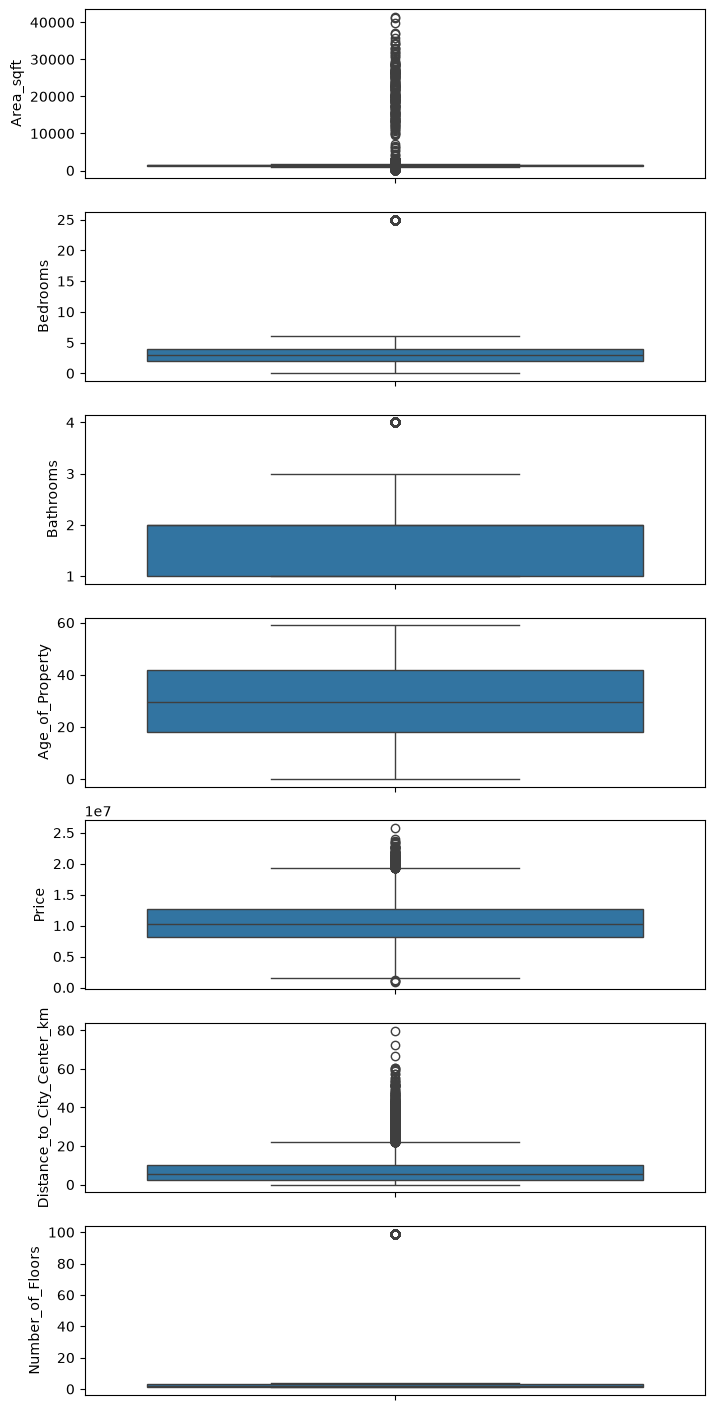

In [13]:
import seaborn as sns

''' Plotting boxplots to see outliers '''
fig, axes = plt.subplots(7,1,figsize =(8,18)) 
for i,col in enumerate(cols):
    sns.boxplot(df[col], ax = axes[i])
plt.show()

##### Handling Outliers With IQR Method

In [14]:
cols = ['Area_sqft','Bedrooms','Bathrooms','Age_of_Property','Price','Distance_to_City_Center_km']

df.loc[df['Number_of_Floors'] == 99, 'Number_of_Floors'] = 3
for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower_limit, upper_limit)


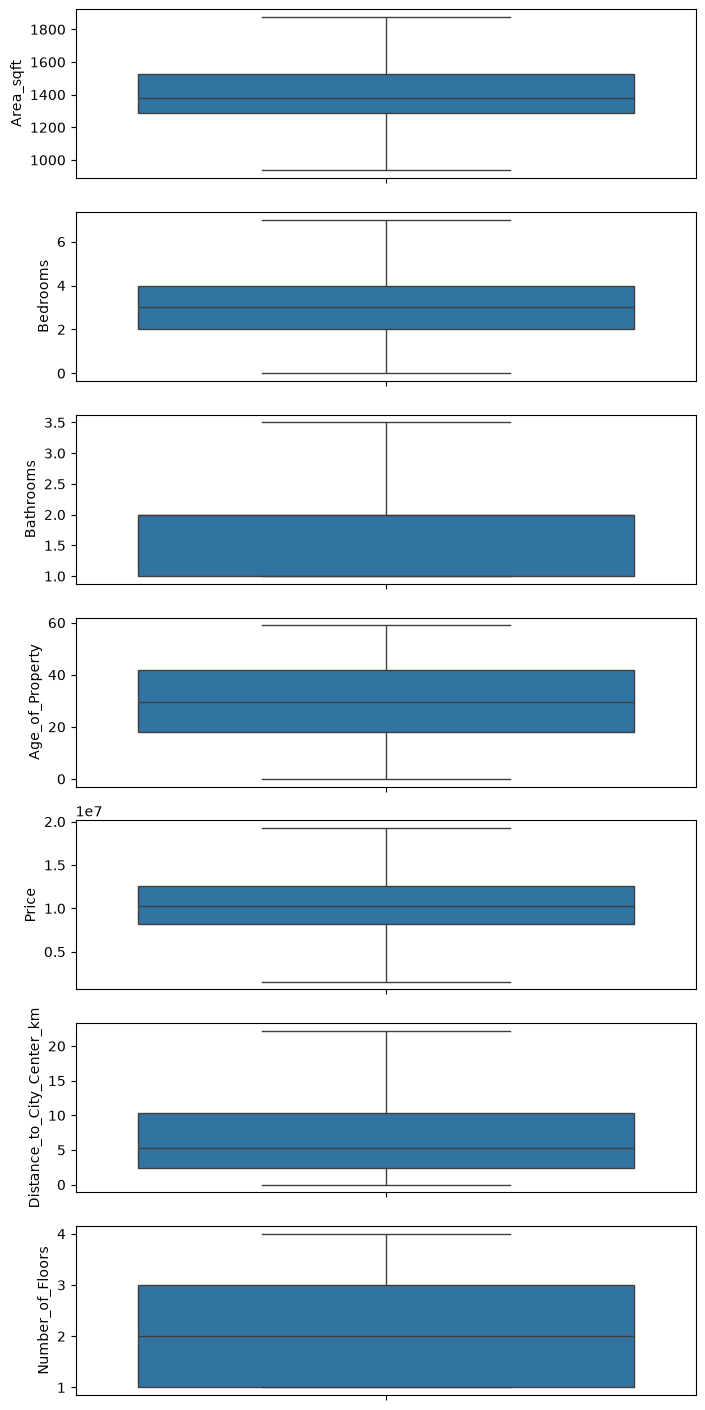

In [15]:
cols = ['Area_sqft','Bedrooms','Bathrooms','Age_of_Property','Price','Distance_to_City_Center_km','Number_of_Floors']

''' Plotting boxplots to check outliers after applying IQR Method '''
fig, axes = plt.subplots(7,1,figsize =(8,18)) 
for i,col in enumerate(cols):
    sns.boxplot(df[col], ax = axes[i])
plt.show()

In [16]:
### Here, we can see that there are no outliers and our data cleaning process is completed.

### Saving Dataset

In [17]:
df.to_csv('house_prediction_dataset_cleaned.csv') # dataframe saved in csv format

## Feature Enginnering

In [18]:
# Creating useful features with existing features
df['Years_since_Listed'] = pd.Timestamp.today().year - df['Date_Listed'].dt.year
df['Bedroom_bathroom_ratio'] = df['Bedrooms'] / df['Bathrooms']
df['Age_of_Property_till_now'] = df['Years_since_Listed'] + df['Age_of_Property']
df['Total_Rooms'] = df['Bedrooms'] + df['Bathrooms']

# Removing useless columns for prediction
df = df.drop(columns = ['House_ID','Age_of_Property','Date_Listed'])
# Putting target at the end
target = df.pop('Price')
df['Price'] = target


## Feature Encoding

In [19]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

ordinal_encoder = OrdinalEncoder(categories= [['Unfurnished','Semi Furnished','Furnished'],['First Owner','Second Owner','Third Owner']])

# Label Encoding with map function
dict_yes_no = {'Yes' : 1, 'No': 0}
df['Parking_Available'] = df['Parking_Available'].map(dict_yes_no)
df['Has_Garden'] = df['Has_Garden'].map(dict_yes_no)

# Ordinal Encoding o
df[['Furnishing_Status','Owner_Type']] = ordinal_encoder.fit_transform(df[['Furnishing_Status','Owner_Type']])

# One Hot Encoding
one_hot_encoder = OneHotEncoder(handle_unknown= 'ignore', sparse_output= False)
values = one_hot_encoder.fit_transform(df[['City']])
new_cols = one_hot_encoder.get_feature_names_out(['City'])
new_df = pd.DataFrame(values, columns = new_cols, index = df.index)
df = pd.concat([df.drop(columns = ['City']), new_df],axis = 1 )

# Putting target at the end
target = df.pop('Price')
df['Price'] = target

## Train/Test Split

In [20]:
from sklearn.model_selection import train_test_split

# Splitting into features and target
X = np.array(df.drop(columns = ['Price']))
y = np.array(df['Price'])

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

## Feature Scaling

In [21]:
from sklearn.preprocessing import StandardScaler

#  Feature Scaling using StandardScaler which calculates mean and standard deviation.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [34]:
df.to_csv('house_price_prediction_ready_to_use.csv')

## Model 1: DecisionTreeRegressor

In [22]:
from sklearn.tree import DecisionTreeRegressor
from scipy.stats import randint

reg = DecisionTreeRegressor(
ccp_alpha =  0.01,
 criterion = 'squared_error',
 max_depth = 24,
 max_features = None,
 max_leaf_nodes = 364,
 min_samples_leaf = 9,
 min_samples_split = 18,
 splitter = 'best')
reg.fit(X_train_scaled, y_train)

y_pred = reg.predict(X_test_scaled)
print('R2 Score: ',r2_score(y_test, y_pred))
print('Training Score: ', reg.score(X_train_scaled, y_train))
print('Testing Score: ', reg.score(X_test_scaled, y_test))
print('MSE: ',mean_squared_error(y_test, y_pred))
print('MAE: ',mean_absolute_error(y_test, y_pred))
print('RMSE: ', root_mean_squared_error(y_test, y_pred))

R2 Score:  0.8124432543714083
Training Score:  0.8694575286108525
Testing Score:  0.8124432543714083
MSE:  2021859869171.417
MAE:  1101028.289166557
RMSE:  1421921.1895078493


In [23]:
from sklearn.model_selection import RandomizedSearchCV
param_dist = {
    'criterion': ['squared_error', 'friedman_mse', 'absolute_error'],
    'splitter': ['best', 'random'],
    'max_depth': randint(2, 50),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 20),
    'max_features': [None, 'sqrt', 'log2'],
    'max_leaf_nodes': randint(10, 500),
    'ccp_alpha': [0.0, 0.001, 0.01, 0.1]
}
dtr = DecisionTreeRegressor(random_state=42)

random_cv = RandomizedSearchCV(
    estimator=dtr,
    param_distributions=param_dist,
    n_iter=100,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=2)
random_cv.fit(X_train_scaled, y_train)

print("Best Parameters:")
print(random_cv.best_params_)


print("\nBest CV R² Score:")
print(random_cv.best_score_)



best_model = random_cv.best_estimator_

y_pred = best_model.predict(X_test)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


d:\scikit-learn.py\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:489: FitFailedWarning: 
180 fits failed out of a total of 500.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
114 fits failed with the following error:
Traceback (most recent call last):
  File "d:\scikit-learn.py\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 851, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "d:\scikit-learn.py\.venv\Lib\site-packages\sklearn\base.py", line 1393, in wrapper
    estimator._validate_params()
  File "d:\scikit-learn.py\.venv\Lib\site-packages\sklearn\base.py", line 554, in _validate_params
    validate_parameter_constraints(
  File "d:\scikit-learn.py\.venv\Lib\site-packag

Best Parameters:
{'ccp_alpha': 0.01, 'criterion': 'squared_error', 'max_depth': 24, 'max_features': None, 'max_leaf_nodes': 364, 'min_samples_leaf': 9, 'min_samples_split': 18, 'splitter': 'best'}

Best CV R² Score:
0.8114445789569166


## Model 2: Support Vector Regressor 

In [ ]:
from sklearn.svm import SVR
reg = SVR(kernel= 'rbf')
reg.fit(X_train_scaled, y_train)
y_pred = reg.predict(X_test_scaled)
print('R2 Score: ',r2_score(y_test, y_pred))
print('Training Score: ', reg.score(X_train_scaled, y_train))
print('Testing Score: ', reg.score(X_test_scaled, y_test))
print('MSE: ',mean_squared_error(y_test, y_pred))
print('MAE: ',mean_absolute_error(y_test, y_pred))
print('RMSE: ', root_mean_squared_error(y_test, y_pred))

R2 Score:  -0.0035840482347890834
Training Score:  -0.0030236857101650916
Testing Score:  -0.0035840482347890834
MSE:  10818626147868.014
MAE:  2623277.4628325133
RMSE:  3289168.0023781112


## Model 3: KNeighbors Regressor


In [ ]:
from sklearn.neighbors import KNeighborsRegressor

reg = KNeighborsRegressor(n_neighbors= 8,weights= 'uniform')
reg.fit(X_train_scaled, y_train)
y_pred = reg.predict(X_test_scaled)
print('R2 Score: ',r2_score(y_test, y_pred))
print('Training Score: ', reg.score(X_train_scaled, y_train))
print('Testing Score: ', reg.score(X_test_scaled, y_test))
print('MSE: ',mean_squared_error(y_test, y_pred))
print('MAE: ',mean_absolute_error(y_test, y_pred))
print('RMSE: ', root_mean_squared_error(y_test, y_pred))

R2 Score:  0.753957721052641
Training Score:  0.8087325990649757
Testing Score:  0.753957721052641
MSE:  2652333341868.9355
MAE:  1268795.7048238716
RMSE:  1628598.5821770004


In [33]:
from sklearn.ensemble import BaggingRegressor
bag = BaggingRegressor(
    estimator = SVR(),
    n_estimators= 100,
    max_samples = 0.4,
    bootstrap = True,
    random_state = 42,
    n_jobs  = -1
)
bag.fit(X_train_scaled,y_train)
y_pred = bag.predict(X_test_scaled)
print('R2 score: ',r2_score(y_test,y_pred))
print('Training score:',bag.score(X_train_scaled,y_train))
print('Testing Score: ',bag.score(X_test_scaled,y_test))

R2 score:  -0.0037422261040154225
Training score: -0.0031810729633987567
Testing Score:  -0.0037422261040154225


In [26]:
param_dist = {'n_neighbors' : randint(1,40)}
random_cv = RandomizedSearchCV(estimator = reg, 
                               param_distributions= param_dist,
                               cv  = 5, 
                               n_iter = 10,
                               random_state = 42, 
                               scoring = 'r2')
random_cv.fit(X_train_scaled, y_train)
print('Best Score')
print(random_cv.best_score_)
print('Best Parameters')
print(random_cv.best_params_)

Best Score
0.74010094222031
Best Parameters
{'n_neighbors': 8}


In [35]:
df.shape

(18000, 21)